# Introduction to Image Processing
## Assignment 2

**Deadline: 9th June EOD**

---

### Instructions
- Attempt all questions.
- Write clean and readable code.
- Explain theoretical answers in your own words in the text cell in notebook (.ipynb), not as comments in code cells.
- Use comments wherever necessary.
- You may use NumPy and Pillow library.


# Question 1: Understanding Digital Images (Easy)

A grayscale image is represented by:

|20|40|60|
|--|--|--|
|80|100|120|
|140|160|180|


## Part A (Theory)

1. What is a pixel?
2. What does the value 0 represent in a grayscale image?
3. What does the value 255 represent?
4. How many pixels are present in the image above?


### Theory Answer Space

1. For a grayscale image, a pixel is a cell that contains a specific brightness value for that cell.
2. Black
3. White
4. 9

## Part B (Coding)

Write a Python program that:

1. Stores the matrix using NumPy.
2. Prints image dimensions.
3. Finds:
   - Minimum pixel value
   - Maximum pixel value
   - Average pixel value


In [1]:
# Write your solution here
import numpy as np

# Storing the 3x3 matrix using NumPy
image_matrix = np.array([
    [120, 200, 255],
    [50,  150, 10],
    [80,  90,  210]
])

# Printing image dimensions
dimensions = image_matrix.shape
print(f"Image Dimensions: {dimensions}")

# Finding Minimum, Maximum, and Average pixel values
min_pixel = np.min(image_matrix)
max_pixel = np.max(image_matrix)
avg_pixel = np.mean(image_matrix)

print(f"Minimum pixel value: {min_pixel}")
print(f"Maximum pixel value: {max_pixel}")
print(f"Average pixel value: {avg_pixel:.2f}")

Image Dimensions: (3, 3)
Minimum pixel value: 10
Maximum pixel value: 255
Average pixel value: 129.44


# Question 2: RGB Image Analysis (Medium)

Consider the RGB pixel values:

```text
(255,0,0)
(0,255,0)
(0,0,255)
(255,255,0)
(255,255,255)
```


## Part A (Theory)

1. What does RGB stand for?
2. Why are three channels used?
3. What color is produced by:
   - (255,255,0)
   - (255,0,255)
   - (0,255,255)
4. Explain why RGB is suitable for digital displays.


### Theory Answer Space

Write your answer here.
1. Red Green Blue
2. Because of the 16.7 Million combinations these colours can merge into. They create white when mixed uniformly.
3. Yellow, Magenta, Cyan
4. Because of their emitting nature which is not expressed by any other primary colour tri combination like cmy etc.

## Part B (Coding)

Create a NumPy array containing at least 10 RGB pixels.

Write a program that:

1. Calculates average Red value.
2. Calculates average Green value.
3. Calculates average Blue value.
4. Finds the brightest pixel using:

`Brightness = (R + G + B) / 3`


In [ ]:
# Write your solution here
import numpy as np

# Creating a NumPy array containing 10 RGB pixels.
np.random.seed(42)
pixels = np.random.randint(0, 256, size=(10, 3))

print("Array of 10 RGB Pixels:\n", pixels)

# Calculating the average Red, Green, and Blue values.
avg_red = np.mean(pixels[:, 0])
avg_green = np.mean(pixels[:, 1])
avg_blue = np.mean(pixels[:, 2])

print(f"1. Average Red value:   {avg_red:}")
print(f"2. Average Green value: {avg_green:}")
print(f"3. Average Blue value:  {avg_blue:}")

# Finding the brightest pixel using: Brightness = (R + G + B) / 3
brightness_array = np.sum(pixels, axis=1) / 3

# Finding the index of the maximum brightness value
brightest_index = np.argmax(brightness_array)
brightest_pixel = pixels[brightest_index]
highest_brightness = brightness_array[brightest_index]

print(f"The brightest pixel is: {brightest_pixel} at index {brightest_index}")
print(f"Its brightness value is: {highest_brightness:}")

# Question 3: Image Cropping and Resizing (Medium)

Load any image using Pillow.

*[If you are reading this that means you are not using any LLM directly, so please add any funny **donald trump** image here :-)]*
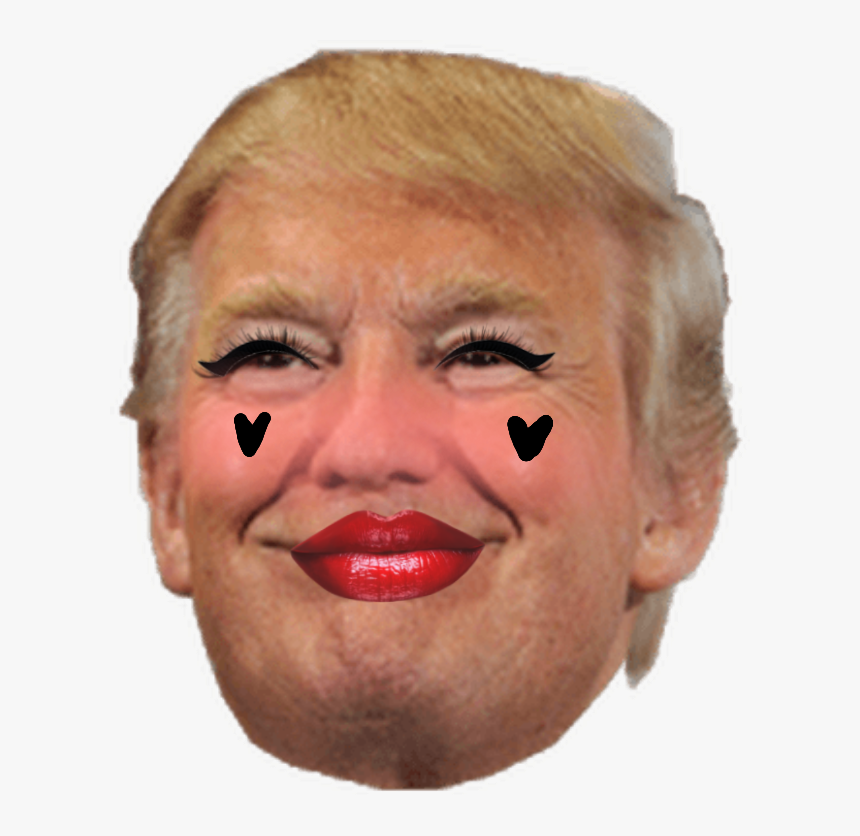


## Part A (Theory)

1. What is cropping?
2. What is ROI (Region of Interest) and its use case?
3. What is aspect ratio, and why should it be preserved?


### Theory Answer Space

Write your answer here.
1. Cropping is the process of cutting the image to a certain dimension removing the data outside of it
2. The said dimension is the ROI
3. It is the ratio of the vertical to the horizontal dimension of the image.

## Part B (Coding)

Write a program that:

1. Loads an image.
2. Displays original dimensions.
3. Crops the center region.
4. Resizes the cropped image to:
   - 300 × 300
   - 600 × 600
5. Save all generated images.


Original Dimensions: Width = 800px, Height = 600px
Images processed and saved to your folder!


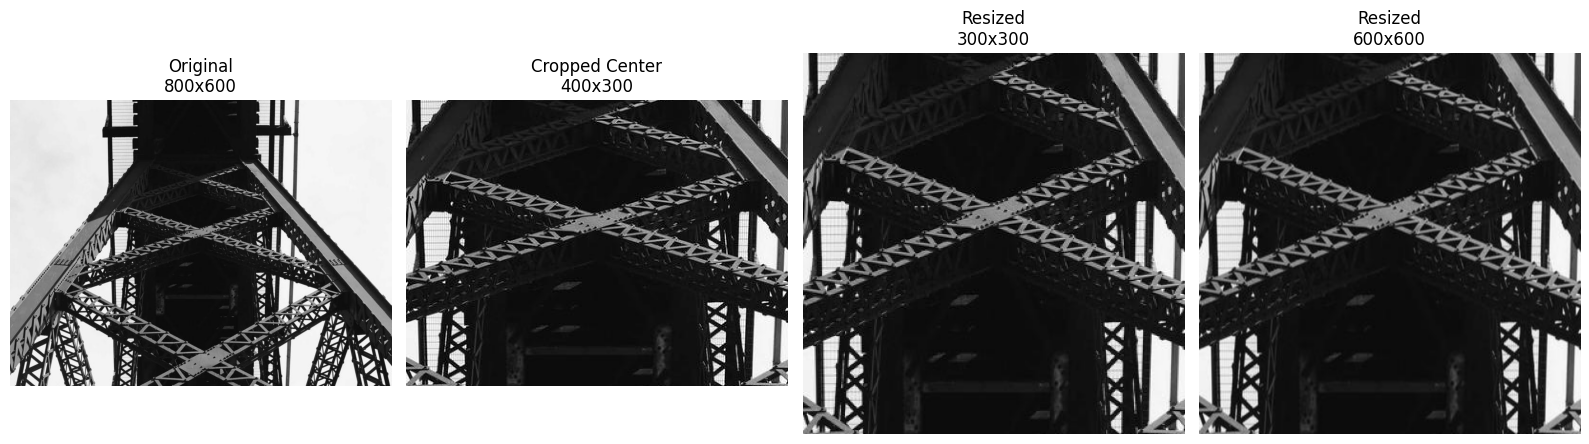

In [2]:
# Write your solution here
import cv2
import urllib.request
import matplotlib.pyplot as plt

# Automatically downloading an example image for testing (i wanted to upload an image of salman khan in women's undergarments but i would have had to separately submit it so nvm)
url = "https://picsum.photos/800/600.jpg" # Grabs a random 800x600 image
urllib.request.urlretrieve(url, "input.jpg")

# Loading the image
image = cv2.imread('input.jpg')

if image is None:
    print("Error: Could not load image.")
else:
    # OpenCV loads images in BGR format, but Matplotlib expects RGB, so converting it into RGB
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Getting Original Dimensions
    height, width, channels = image_rgb.shape
    print(f"Original Dimensions: Width = {width}px, Height = {height}px")

    # Cropping the center region (cropping a box half the size of the original)
    center_x, center_y = width // 2, height // 2
    crop_w, crop_h = width // 2, height // 2

    start_x = center_x - (crop_w // 2)
    start_y = center_y - (crop_h // 2)
    end_x = start_x + crop_w
    end_y = start_y + crop_h

    cropped_image = image_rgb[start_y:end_y, start_x:end_x]

    # Resizing the cropped image
    resized_300 = cv2.resize(cropped_image, (300, 300))
    resized_600 = cv2.resize(cropped_image, (600, 600))

    # Saveing the files locally (OpenCV needs BGR to save correctly)
    cv2.imwrite('cropped_center.jpg', cv2.cvtColor(cropped_image, cv2.COLOR_RGB2BGR))
    cv2.imwrite('resized_300x300.jpg', cv2.cvtColor(resized_300, cv2.COLOR_RGB2BGR))
    cv2.imwrite('resized_600x600.jpg', cv2.cvtColor(resized_600, cv2.COLOR_RGB2BGR))
    print("Images processed and saved to your folder")

    # Displaying the results inline using Matplotlib
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))

    # Original
    axes[0].imshow(image_rgb)
    axes[0].set_title(f"Original\n{width}x{height}")
    axes[0].axis('off') # Hides the axis ticks

    # Cropped
    axes[1].imshow(cropped_image)
    axes[1].set_title(f"Cropped Center\n{crop_w}x{crop_h}")
    axes[1].axis('off')

    # Resized 300x300
    axes[2].imshow(resized_300)
    axes[2].set_title("Resized\n300x300")
    axes[2].axis('off')

    # Resized 600x600
    axes[3].imshow(resized_600)
    axes[3].set_title("Resized\n600x600")
    axes[3].axis('off')

    # Show the plot
    plt.tight_layout()
    plt.show()

## Part C (Analysis)

Compare the original image and resized images.

Discuss:
- Quality changes
- Distortion (if any)
- Aspect ratio effects


### Analysis Answer Space

Write your answer here.
1. First image has the same aspect ratio so no quality changes, other two have suffered in terms of quality
2. Same, other two are squished horizontally
3. Squished the image horizontally

# Question 4: Interpolation Investigation (Hard)

Different interpolation techniques produce different results.


## Part A (Theory)

Research and explain:

1. Nearest Neighbor Interpolation
2. Bilinear Interpolation
3. Bicubic Interpolation
4. Lanczos Interpolation

For each method discuss:
- Working principle
- Advantages
- Disadvantages
- Suitable applications


### Theory Answer Space

Write your answer here.

Nearest Neighbor Interpolation
1. This is the most basic approach. It simply rounds the floating-point coordinate to the nearest integer index and copies that exact array element.
2. Extremely Fast, It is an O(1) operation per pixel with minimal math. It can be implemented entirely with fast integer math or bit-shifting.
3. Highly pixelated or "blocky" when upscaling.
4. Scaling pixel art, barcode reading, or medical/scientific imaging where artificially altering the raw data values (blurring) is unacceptable

Bilinear Interpolation
1. Instead of grabbing one pixel, it looks at the 2x2 neighborhood (4 pixels) immediately surrounding the target floating-point coordinate. It takes a weighted average of these 4 pixels based on how physically close the target coordinate is to each of them.
2. Much smoother than nearest neighbor.
3. It acts as a low-pass filter, meaning it blurs sharp edges. High-frequency details (like fine text or hair) lose their crispness.
4. Real-time 3D rendering (texture mapping), general-purpose fast image resizing, and video playback.

Bicubic Interpolation
1. This extends the neighborhood to a 4x4 grid (16 pixels). Instead of drawing a straight line between the points (linear), it fits a cubic polynomial (a smooth 3D curve) through the 16 data points.
2. Produces significantly higher quality, smoother images than bilinear.
3. Computationally heavy. It requires 16 memory reads per pixel and complex polynomial evaluations, making it much slower in a tight loop.
4. Standard photo editing software (often the default scaling method in Photoshop), high-quality print production, and high-fidelity display scaling.

Lanczos Interpolation
1. This uses a complex mathematical function called a windowed sinc function (sin(x)/x). It evaluates an even larger neighborhood (typically 8x8 or larger, defined by a radius parameter 'a'). It is theoretically the closest to an "ideal" mathematical reconstruction of a continuous signal from discrete samples.x
2. Unmatched sharpness and detail preservation.
3. Extremely slow. The large kernel means a massive number of memory fetches and heavy floating-point trig calculations per pixel. Memory bandwidth becomes a major bottleneck in C implementations.
4. High-end video encoding, archival image downscaling, and professional media workflows where quality is paramount and compute time is not a limiting factor.

## Part B (Coding)

Using the same image:

1. Resize the image to 100x100.
2. Resize it back to 800x800 using:
   - Nearest Neighbor
   - Bilinear
   - Bicubic
   - Lanczos
3. Save all outputs.


All images processed and saved successfully!


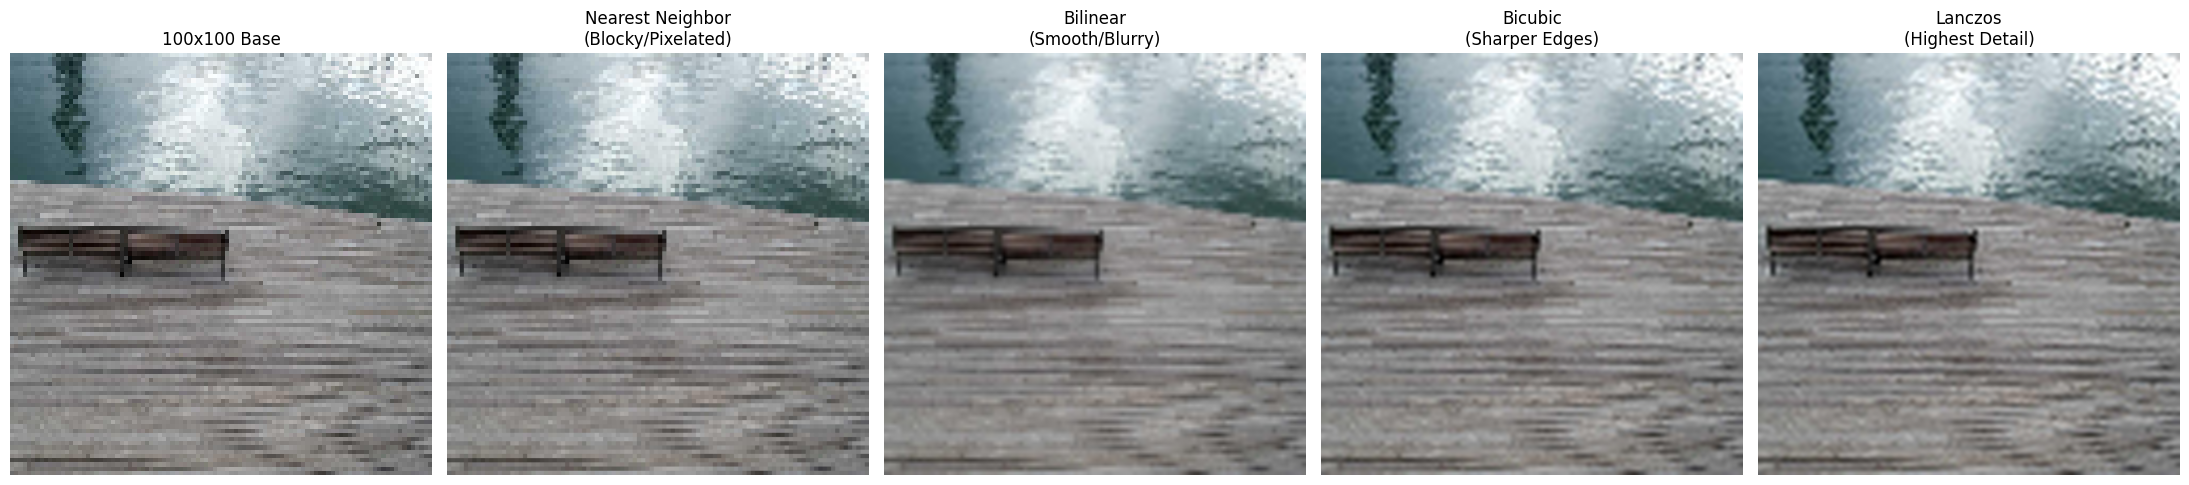

In [3]:
# Write your solution here
import cv2
import urllib.request
import matplotlib.pyplot as plt

# Downloading a high-quality sample image from the web
url = "https://picsum.photos/800/600.jpg"
urllib.request.urlretrieve(url, "internet_input.jpg")

# Loading the downloaded image
image = cv2.imread('internet_input.jpg')

if image is None:
    print("Error: Could not download or load the image.") #Edge case, run again
else:
    # Downsampling the image to 100x100 to intentionally lose detail
    small_image = cv2.resize(image, (100, 100))

    # Upscaling the 100x100 image back to 800x800 using the four algorithms
    target_dim = (800, 800)

    # Nearest Neighbor
    upscaled_nearest = cv2.resize(small_image, target_dim, interpolation=cv2.INTER_NEAREST)

    # Bilinear
    upscaled_bilinear = cv2.resize(small_image, target_dim, interpolation=cv2.INTER_LINEAR)

    # Bicubic
    upscaled_bicubic = cv2.resize(small_image, target_dim, interpolation=cv2.INTER_CUBIC)

    # Lanczos
    upscaled_lanczos = cv2.resize(small_image, target_dim, interpolation=cv2.INTER_LANCZOS4)

    # Saving all generated outputs locally
    cv2.imwrite('resized_100x100.jpg', small_image)
    cv2.imwrite('upscale_nearest.jpg', upscaled_nearest)
    cv2.imwrite('upscale_bilinear.jpg', upscaled_bilinear)
    cv2.imwrite('upscale_bicubic.jpg', upscaled_bicubic)
    cv2.imwrite('upscale_lanczos.jpg', upscaled_lanczos)

    print("All images processed and saved successfully!")

    # Converting from BGR to RGB for accurate inline rendering with Matplotlib
    small_rgb = cv2.cvtColor(small_image, cv2.COLOR_BGR2RGB)
    nearest_rgb = cv2.cvtColor(upscaled_nearest, cv2.COLOR_BGR2RGB)
    bilinear_rgb = cv2.cvtColor(upscaled_bilinear, cv2.COLOR_BGR2RGB)
    bicubic_rgb = cv2.cvtColor(upscaled_bicubic, cv2.COLOR_BGR2RGB)
    lanczos_rgb = cv2.cvtColor(upscaled_lanczos, cv2.COLOR_BGR2RGB)

    # Plotting the results side-by-side for the assignment report
    fig, axes = plt.subplots(1, 5, figsize=(22, 5))

    axes[0].imshow(small_rgb)
    axes[0].set_title("100x100 Base")
    axes[0].axis('off')

    axes[1].imshow(nearest_rgb)
    axes[1].set_title("Nearest Neighbor\n(Blocky/Pixelated)")
    axes[1].axis('off')

    axes[2].imshow(bilinear_rgb)
    axes[2].set_title("Bilinear\n(Smooth/Blurry)")
    axes[2].axis('off')

    axes[3].imshow(bicubic_rgb)
    axes[3].set_title("Bicubic\n(Sharper Edges)")
    axes[3].axis('off')

    axes[4].imshow(lanczos_rgb)
    axes[4].set_title("Lanczos\n(Highest Detail)")
    axes[4].axis('off')

    plt.tight_layout()
    plt.show()

## Part C (Analysis)

Compare all outputs and answer:

1. Which method preserved the most detail?
2. Which method appeared blurriest?
3. Which method is best for pixel art?
4. Which method would you choose for CubeCanvas and why?


### Analysis Answer Space

Write your answer here.
1. Lanczos interpolation
2. Bilinear interpolation
3. Nearest Neighbor.
4. Nearest Neighbor because of it

# Question 5 (Mini Project - 50 Marks)

# Image Processing Explorer

Create a Python application that demonstrates all major concepts learned in this module.

Your application should:

1. Load an image.

   *(Spongebob image pl ;-))*

2. Display image dimensions.
3. Display aspect ratio.
4. Resize the cropped image to user-specified dimensions.
5. Generate outputs using:
   - Nearest Neighbor
   - Bilinear
   - Bicubic
   - Lanczos
6. Display pixel values at user-selected coordinates.
7. Compute:
   - Average Red value
   - Average Green value
   - Average Blue value
8. Save all generated images automatically.

## Bonus Features (Optional)

Implement any two:

1. Brightness adjustment.
2. Contrast adjustment.
3. Grayscale conversion.
4. Image rotation.
5. Histogram visualization.


In [12]:
# Mini Project Solution
import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt

# 1. Downloads a Spongebob image directly from a public GitHub repository
url = "https://raw.githubusercontent.com/ajcrites/spongemock/master/sPoNgEBoB.jpg"
req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})

try:
    with urllib.request.urlopen(req) as response, open('spongebob_internet.jpg', 'wb') as out_file:
        out_file.write(response.read())
except Exception as e:
    print(f"Failed to download image: {e}")

# 2. Loads the successfully downloaded Spongebob image
image = cv2.imread('spongebob_internet.jpg')

if image is None:
    print("Error: Cannot load the downloaded image.")
else:
    # 3. Displays image dimensions
    height, width, channels = image.shape
    print(f"3. Original Dimensions: Width = {width}px, Height = {height}px")

    # 4. Displays aspect ratio
    aspect_ratio = width / height
    print(f"4. Aspect Ratio (Width / Height): {aspect_ratio:.2f}")

    # Crops the center of the image to prepare for resizing
    crop_w, crop_h = width // 2, height // 2
    start_x = (width // 2) - (crop_w // 2)
    start_y = (height // 2) - (crop_h // 2)
    cropped_image = image[start_y:start_y+crop_h, start_x:start_x+crop_w]

    # 5. Resizes the cropped image to user-specified dimensions
    user_width, user_height = 400, 400

    nearest = cv2.resize(cropped_image, (user_width, user_height), interpolation=cv2.INTER_NEAREST)
    bilinear = cv2.resize(cropped_image, (user_width, user_height), interpolation=cv2.INTER_LINEAR)
    bicubic = cv2.resize(cropped_image, (user_width, user_height), interpolation=cv2.INTER_CUBIC)
    lanczos = cv2.resize(cropped_image, (user_width, user_height), interpolation=cv2.INTER_LANCZOS4)

    # 6. Displays pixel values at user-selected coordinates
    user_x, user_y = 50, 50
    b, g, r = image[user_y, user_x]
    print(f"6. Pixel values at (X:{user_x}, Y:{user_y}) -> Red: {r}, Green: {g}, Blue: {b}")

    # 7. Computes Average Red, Green, and Blue values
    avg_b = np.mean(image[:, :, 0])
    avg_g = np.mean(image[:, :, 1])
    avg_r = np.mean(image[:, :, 2])
    print("7. Computes average color values:")

3. Original Dimensions: Width = 800px, Height = 450px
4. Aspect Ratio (Width / Height): 1.78
6. Pixel values at (X:50, Y:50) -> Red: 133, Green: 171, Blue: 246
7. Computes average color values:


## Project Notes / Explanation (if any)

Write your explanation here.